# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import scanpy as sc

from matplotlib.pyplot import rcParams
import matplotlib.pyplot as plt
import seaborn as sns

/home/icb/amirali.moinfar/miniconda3/envs/drvi_repr/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/icb/amirali.moinfar/miniconda3/envs/drvi_repr/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/icb/amirali.moinfar/miniconda3/envs/drvi_repr/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/icb/amirali.moinfar/miniconda3/envs/drvi_repr/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/home/icb/amirali.moinfar/miniconda3/e

In [3]:
import warnings
# warnings.filterwarnings(action='once')
warnings.filterwarnings('ignore')

In [4]:
import os

import scanpy as sc
import pandas as pd
from pathlib import Path
from collections import OrderedDict
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from drvi_notebooks.utils.method_info import pretify_method_name

# Config

In [6]:
cwd = os.getcwd()
cwd

'/ictstr01/home/icb/amirali.moinfar/projects/drvi_reproducibility_public/drvi_notebooks/evaluation'

In [7]:
proj_dir = Path(cwd).parent.parent
proj_dir

PosixPath('/ictstr01/home/icb/amirali.moinfar/projects/drvi_reproducibility_public')

In [8]:
logs_dir = Path(os.path.expanduser('~/workspace/train_logs'))
logs_dir

PosixPath('/home/icb/amirali.moinfar/workspace/train_logs')

In [9]:
import mplscience
mplscience.available_styles()
mplscience.set_style()

['default', 'despine']


In [10]:
cat_10_pallete = sc.plotting.palettes.vega_10_scanpy
cat_20_pallete = sc.plotting.palettes.vega_20_scanpy
wong_pallete = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#000000",
]
cat_100_pallete = sc.plotting.palettes.godsnot_102

## Runs to load

In [11]:
datasets = OrderedDict([
    ('pancreas_scvelo', dict(
        name='Developmental\npancreas',
    )),
    ('hlca', dict(
        name='Human lung\ncell atlas',
    )),
    ('norman_hvg', dict(
        name='CRISPR screen\n',
        # name='Norman\nPerturb-seq',
    )),
    ('retina_organoid_hvg', dict(
        name='Retina organoid\n',
    )),
    ('immune_hvg', dict(
        name='Immune\n',
    )),
    ('pbmc_covid_hvg', dict(
        name='PBMC\n',
    )),
    ('zebrafish_hvg', dict(
        # name='Zebrafish\n',
        name='Daniocell\n',
    )),
])
datasets

OrderedDict([('pancreas_scvelo', {'name': 'Developmental\npancreas'}),
             ('hlca', {'name': 'Human lung\ncell atlas'}),
             ('norman_hvg', {'name': 'CRISPR screen\n'}),
             ('retina_organoid_hvg', {'name': 'Retina organoid\n'}),
             ('immune_hvg', {'name': 'Immune\n'}),
             ('pbmc_covid_hvg', {'name': 'PBMC\n'}),
             ('zebrafish_hvg', {'name': 'Daniocell\n'})])

In [12]:
col_order = [datasets[ds_name]['name'] for ds_name in ['pancreas_scvelo', 'zebrafish_hvg', 'norman_hvg', 'retina_organoid_hvg', 'immune_hvg', 'hlca', 'pbmc_covid_hvg']]
col_order

['Developmental\npancreas',
 'Daniocell\n',
 'CRISPR screen\n',
 'Retina organoid\n',
 'Immune\n',
 'Human lung\ncell atlas',
 'PBMC\n']

In [13]:
scib_results_df = []
for ds_name, ds_info in datasets.items():
    scib_results_address = proj_dir / 'results' / f'scib_results_{ds_name}.csv'
    if os.path.exists(scib_results_address):
        tmp_df = pd.read_csv(scib_results_address, index_col=0).reset_index(names='method')
        tmp_df['dataset_id'] = ds_name
        tmp_df['dataset'] = ds_info['name']
        tmp_df = pd.melt(tmp_df, id_vars=['dataset_id', 'dataset', 'method'], var_name='metric', value_name='metric_value')
        scib_results_df.append(tmp_df)
scib_results_df = pd.concat(scib_results_df).reset_index(drop=True)
scib_results_df['method'] = scib_results_df['method'].apply(pretify_method_name)
scib_results_df

,dataset_id,dataset,method,metric,metric_value
0,hlca,Human lung\ncell atlas,DRVI,isolated_labels,0.690246
1,hlca,Human lung\ncell atlas,DRVI-AP,isolated_labels,0.622554
2,hlca,Human lung\ncell atlas,scVI,isolated_labels,0.639873
3,hlca,Human lung\ncell atlas,PCA,isolated_labels,0.596167
4,hlca,Human lung\ncell atlas,ICA,isolated_labels,0.608109
...,...,...,...,...,...
567,pbmc_covid_hvg,PBMC\n,B-TCVAE,Total,0.483509
568,pbmc_covid_hvg,PBMC\n,MICHIGAN default,Total,0.474426
569,pbmc_covid_hvg,PBMC\n,LIGER,Total,0.558283
570,pbmc_covid_hvg,PBMC\n,scETM,Total,0.540110


In [14]:
# Remove TCVAE and MICHIGAN and keep hyper-parameters optimized versions
REMOVE_UNOPTIMIZED = True
if REMOVE_UNOPTIMIZED:
    scib_results_df = scib_results_df[~(scib_results_df['method'].isin(['B-TCVAE default', 'MICHIGAN default']))]
scib_results_df

,dataset_id,dataset,method,metric,metric_value
0,hlca,Human lung\ncell atlas,DRVI,isolated_labels,0.690246
1,hlca,Human lung\ncell atlas,DRVI-AP,isolated_labels,0.622554
2,hlca,Human lung\ncell atlas,scVI,isolated_labels,0.639873
3,hlca,Human lung\ncell atlas,PCA,isolated_labels,0.596167
4,hlca,Human lung\ncell atlas,ICA,isolated_labels,0.608109
...,...,...,...,...,...
566,pbmc_covid_hvg,PBMC\n,MOFA,Total,0.566714
567,pbmc_covid_hvg,PBMC\n,B-TCVAE,Total,0.483509
569,pbmc_covid_hvg,PBMC\n,LIGER,Total,0.558283
570,pbmc_covid_hvg,PBMC\n,scETM,Total,0.540110


In [15]:
method_order=[
    'DRVI', 
    'DRVI-AP', 
    'scVI', 
    # 'TCVAE', 
    'B-TCVAE', 
    # 'MICHIGAN', 
    'MICHIGAN',
    'PCA', 
    'ICA', 
    'MOFA',
    'LIGER',
    'scETM',
    # 'DRVI-elu-1',
]
# method_palette = dict(zip(method_order, cat_10_pallete))
method_palette = dict(zip(method_order, cat_20_pallete))

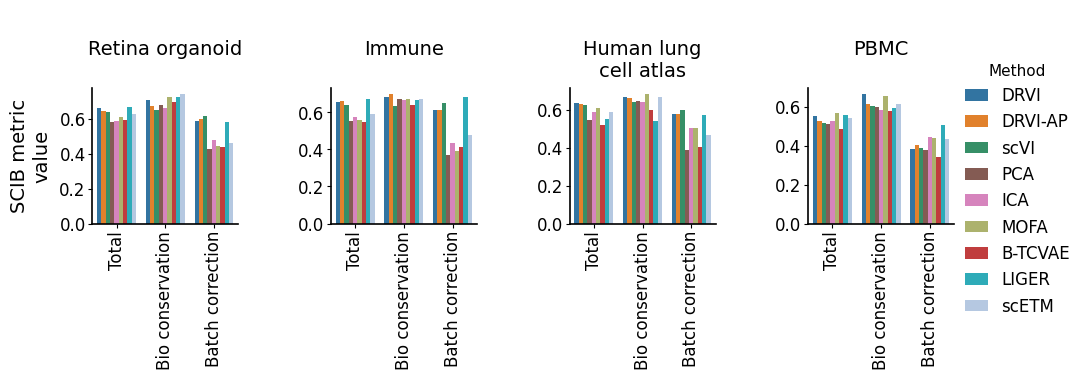

In [16]:
metrics_to_plot = ['Total', 'Bio conservation', 'Batch correction']
plot_df = scib_results_df[scib_results_df['metric'].isin(
    metrics_to_plot
)].copy()
plot_df = plot_df[plot_df['method'].isin(method_palette.keys())]
plot_df = plot_df.rename(columns={'method': 'Method'})
g = sns.catplot(
    data=plot_df, x="metric", y="metric_value", col="dataset", hue="Method", order=metrics_to_plot,
    kind="bar", height=3, aspect=.8, sharey=False, col_order=[ds for ds in col_order if ds in plot_df['dataset'].unique()], palette=method_palette,
)
g.set_xticklabels(rotation=90)
g.set_titles(template='{col_name}')
g.set(xlabel=None)
g.set(ylabel=None)
g.axes[0][0].set(ylabel='SCIB metric\nvalue')
# g.savefig(proj_dir / "plots" / "eval_integration_aggregated.pdf", bbox_inches='tight')
g

In [17]:
import matplotlib
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.formatters import decimal_to_percent
from plottable.plots import bar, circled_image # image

In [18]:
plot_df = scib_results_df[scib_results_df['metric'].isin(
    metrics_to_plot
)].copy()
plot_df = plot_df[plot_df['method'].isin(method_palette.keys())]
plot_df = pd.concat([plot_df, plot_df.groupby(['method', 'metric']).mean().assign(dataset='Average\n').reset_index()])
plot_df = plot_df.pivot(
    index=['dataset', 'metric'], 
    columns='method', 
    values='metric_value'
).reset_index()
plot_df['dataset'] = pd.Categorical(plot_df['dataset'], col_order + ['Average\n'])
plot_df=plot_df.sort_values('dataset')
plot_df = plot_df.assign(
    unique_col=lambda df: df['dataset'].astype(str) + "#" + df['metric']
).drop(columns=['dataset', 'metric']).set_index('unique_col').T
plot_df = plot_df.sort_values(['Average\n#Total'], ascending=False)
plot_df = plot_df.loc[:, [c for c in plot_df.columns if 'Average' not in c] + [c for c in plot_df.columns if 'Average' in c]]
plot_df

unique_col,Retina organoid\n#Batch correction,Retina organoid\n#Bio conservation,Retina organoid\n#Total,Immune\n#Batch correction,Immune\n#Bio conservation,Immune\n#Total,Human lung\ncell atlas#Batch correction,Human lung\ncell atlas#Bio conservation,Human lung\ncell atlas#Total,PBMC\n#Batch correction,PBMC\n#Bio conservation,PBMC\n#Total,Average\n#Batch correction,Average\n#Bio conservation,Average\n#Total
method,,,,,,,,,,,,,,,
DRVI,0.587679,0.707644,0.659658,0.614253,0.680854,0.654214,0.580072,0.669446,0.633696,0.383203,0.662171,0.550584,0.541302,0.680029,0.624538
DRVI-AP,0.595851,0.671807,0.641425,0.609093,0.695513,0.660945,0.578281,0.662478,0.628799,0.400684,0.613685,0.528485,0.545977,0.660871,0.614913
LIGER,0.581345,0.721204,0.665260,0.679179,0.665925,0.671227,0.571346,0.541362,0.553356,0.506230,0.592985,0.558283,0.584525,0.630369,0.612031
scVI,0.616697,0.651451,0.637550,0.649010,0.631901,0.638744,0.599517,0.642305,0.625190,0.387823,0.600747,0.515577,0.563262,0.631601,0.604265
scETM,0.461276,0.738272,0.627474,0.475785,0.669600,0.592074,0.466704,0.668008,0.587486,0.431611,0.612443,0.540110,0.458844,0.672081,0.586786
MOFA,0.442400,0.723400,0.611000,0.388968,0.673531,0.559706,0.503021,0.680616,0.609578,0.438728,0.652039,0.566714,0.443279,0.682396,0.586750
ICA,0.478570,0.663009,0.589233,0.433320,0.663739,0.571572,0.504552,0.642546,0.587349,0.444676,0.580327,0.526067,0.465280,0.637405,0.568555
PCA,0.428056,0.678939,0.578585,0.369927,0.670771,0.550434,0.386062,0.648374,0.543449,0.379603,0.596578,0.509788,0.390912,0.648665,0.545564
B-TCVAE,0.438501,0.692472,0.590884,0.413461,0.640128,0.549462,0.401539,0.596348,0.518424,0.339598,0.579450,0.483509,0.398275,0.627099,0.535570


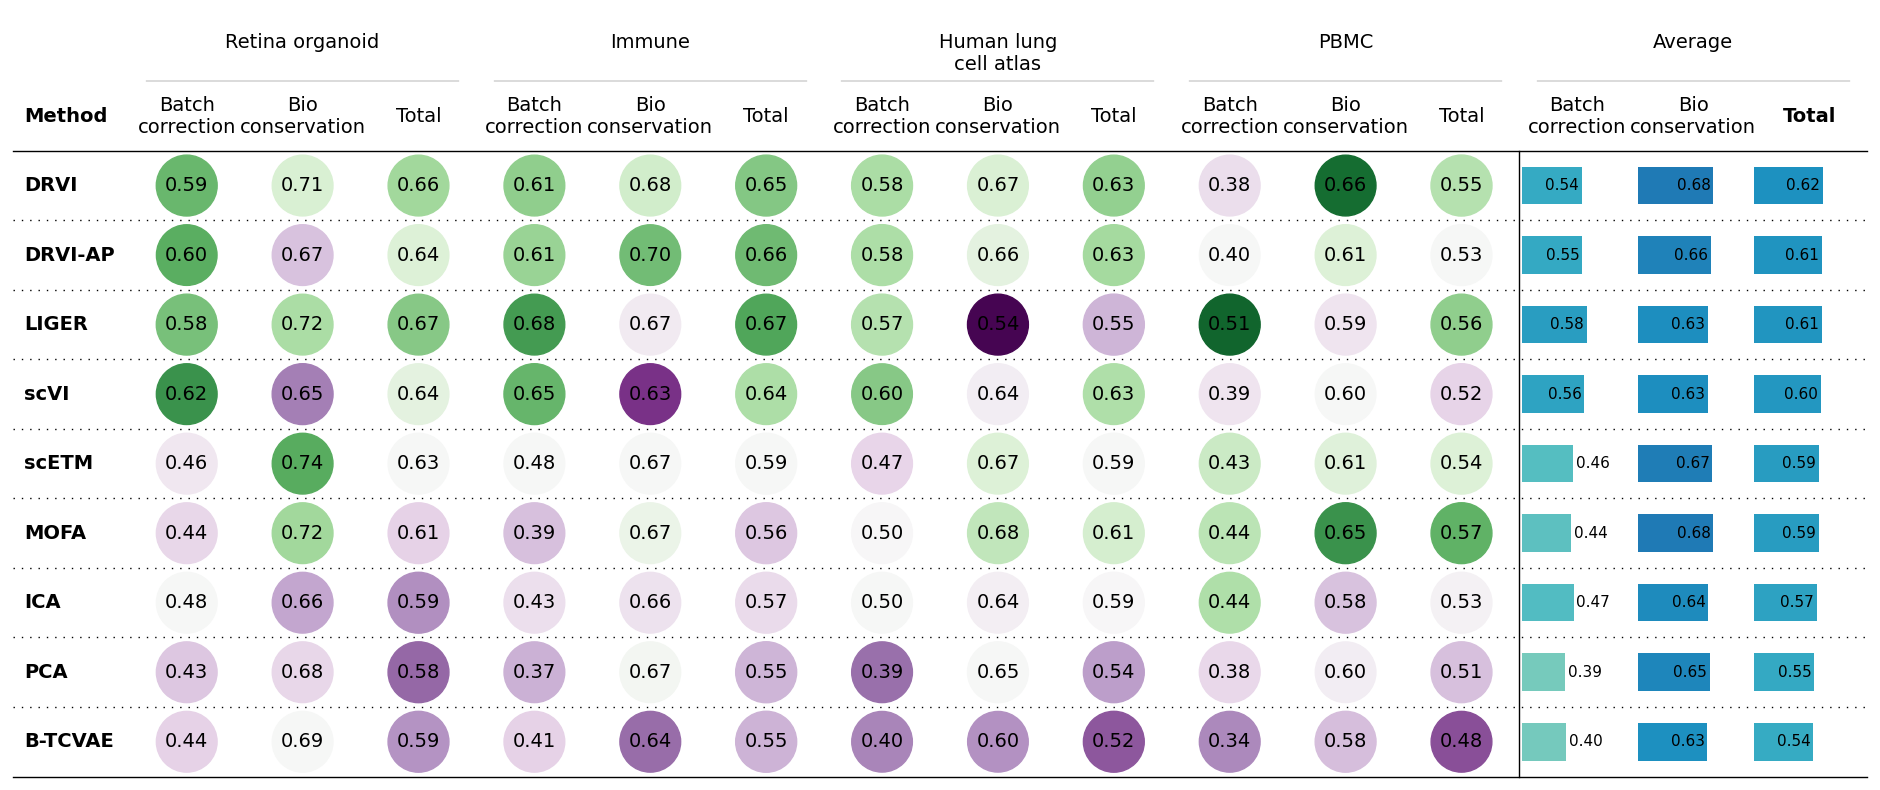

In [19]:
col_defs = (
    [
        ColumnDefinition(
            name="method",
            title="Method",
            textprops={"ha": "left", "weight": "bold"},
            width=1.,
        ),
    ]+
    [
        ColumnDefinition(
            name=col,
            title=col.split("#")[1].replace(" ", "\n"),
            group=col.split("#")[0],
            textprops={
                "ha": "center",
                "bbox": {"boxstyle": "circle", "pad": 0.45},
            },
            cmap=normed_cmap(plot_df[col], cmap=matplotlib.cm.PRGn, num_stds=2.5),
            formatter="{:.2f}",
            width=1.,
        ) if 'Average' not in col else
        ColumnDefinition(
            name=col,
            title=col.split("#")[1].replace(" ", "\n"),
            group=col.split("#")[0],
            textprops={
                "ha": "center",
                **({"weight": "bold"} if col == 'Average\n#Total' else {}),
            },
            plot_fn=bar,
            plot_kw={
                "cmap": matplotlib.cm.YlGnBu,
                "plot_bg_bar": False,
                "annotate": True,
                "height": 0.9,
                "formatter": "{:.2f}",
            },
            formatter="{:.2f}",
            width=1.,
            border="left" if col == "Average\n#Batch correction" else None,
        )
        for col in plot_df.columns
    ]
)
fig, ax = plt.subplots(figsize=(24, 10))
table = Table(
    plot_df,
    column_definitions=col_defs,
    row_dividers=True,
    footer_divider=True,
    ax=ax,
    textprops={"fontsize": 14},
    row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
    col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
    column_border_kw={"linewidth": 1, "linestyle": "-"},
)
fig.savefig(proj_dir / 'plots' / f'eval_integration_scib_summary.pdf', facecolor=ax.get_facecolor(), dpi=300)
plt.show()